# Project: Fashion-MNIST CNN Image Classifier

## Goal: Build a Convolutional Neural Network (CNN) to classify images of clothing into 10 categories like T-shirt, Sneaker, Bag, etc.

### Why CNN?
### Images have spatial patterns (edges, shapes, textures).

### CNNs can automatically detect these patterns, just like a human looking at a picture: first edges, then shapes, then the whole object.

### This makes CNN perfect for image classification tasks, like identifying e-commerce products.

### Import Libraries

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

Load Fashion-MNIST Dataset

Explanation:

X_train → 60,000 images for training (28x28 pixels)

y_train → 60,000 labels (0-9 for clothing categories)

X_test → 10,000 images for testing

y_test → 10,000 labels

Why it’s important:

We need training data to teach the CNN

We need test data to check if the CNN learned correctly

In [6]:
from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Check the shapes
print("Training images:", X_train.shape)
print("Training labels: ", y_train.shape)
print("Test images: ", X_test.shape)
print("Test labels: ", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images: (60000, 28, 28)
Training labels:  (60000,)
Test images:  (10000, 28, 28)
Test labels:  (10000,)


# Visualize Some Images

### The computer (CNN) is like a detective examining these images to find patterns.

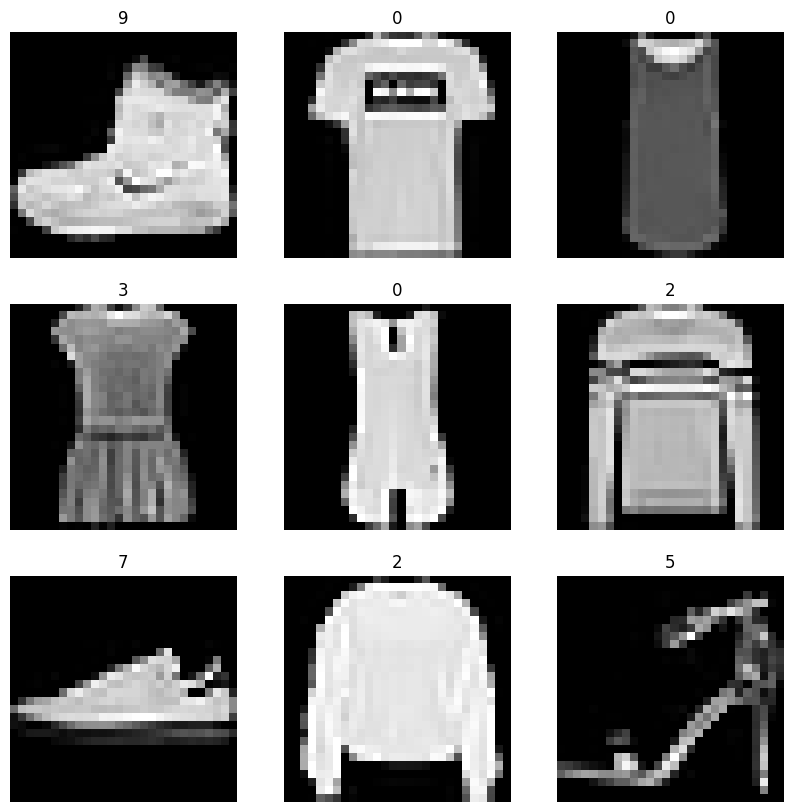

In [7]:
import matplotlib.pyplot as plt

# Show first 9 images
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')
plt.show()

# Preprocess the Data

In [8]:
from tensorflow.keras.utils import to_categorical

# Normalize pixel values (0-255 -> 0-1)
X_train = X_train / 255.0
X_test = X_test / 255.0


# Reshape images to add channel dimension (required for CNN)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)




# Convert labels to one-hot encoding

y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

Build the CNN Model

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    # 1st convolution layer: detect edges
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),  # reduces size, keeps important info

    # 2nd convolution layer: detect shapes
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    # Flatten for fully connected layers
    Flatten(),
    Dense(128, activation='relu'),  # combines patterns
    Dense(10, activation='softmax') # output layer: 10 classes
])

Compile the Model

In [10]:
model.compile(
    optimizer='adam',  # smart way to adjust weights
    loss='categorical_crossentropy',  # good for multi-class
    metrics=['accuracy']  # measure performance
)

Train the Model

In [11]:
history = model.fit(
    X_train, y_train,
    epochs=10,          # number of passes over data
    batch_size=64,      # how many images per update
    validation_split=0.2 # 20% data for validation
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 55ms/step - accuracy: 0.8151 - loss: 0.5158 - val_accuracy: 0.8651 - val_loss: 0.3751
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 87s 61ms/step - accuracy: 0.8763 - loss: 0.3408 - val_accuracy: 0.8872 - val_loss: 0.3115
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 76s 54ms/step - accuracy: 0.8928 - loss: 0.2908 - val_accuracy: 0.8941 - val_loss: 0.2988
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.9056 - loss: 0.2589 - val_accuracy: 0.9020 - val_loss: 0.2704
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.9150 - loss: 0.2313 - val_accuracy: 0.9047 - val_loss: 0.2667
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - accuracy: 0.9224 - loss: 0.2110 - val_accuracy: 0.9084 - val_loss: 0.2491
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - accuracy: 0.9291 - loss: 0.1916 - val_accuracy: 0.9074 - val_loss: 0.2566
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.9348 - loss: 0.1737 - 

Evaluate the Model

In [12]:
# Evaluate on the test dataset
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9121 - loss: 0.2658
Test Accuracy: 0.9121000170707703


Visualize Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


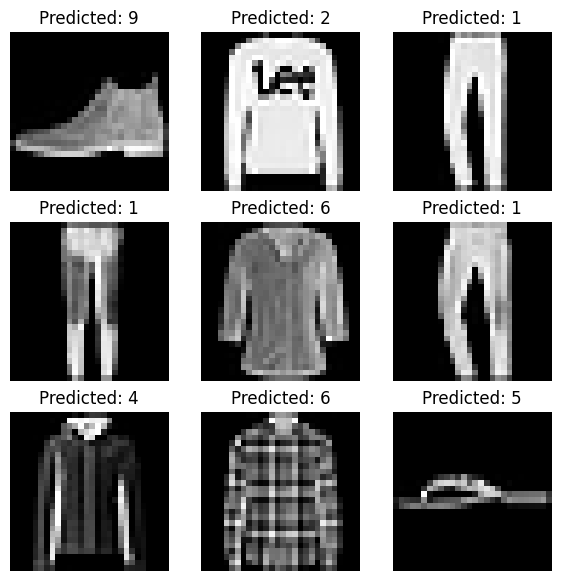

In [13]:
# Predict classes for first 9 test images
predictions = model.predict(X_test[:9])

plt.figure(figsize=(7,7))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title("Predicted: "+ str(np.argmax(predictions[i])))
    plt.axis('off')
plt.show()